In [1]:
import os
import math
from collections import defaultdict
from PIL import Image
import matplotlib.pyplot as plt


In [2]:

# --- Configuration ---
DATA_DIRECTORY = "../data"

LABEL_MAP = {
    1: "Starfish", 2: "Crab", 3: "Black goby", 4: "Wrasse", 
    5: "Two-spotted goby", 6: "Cod", 7: "Painted goby", 8: "Sand eel", 
    9: "Whiting"
}

# --- Helper Functions ---

def gcd(a, b):
    """Calculates the Greatest Common Divisor of two numbers."""
    while b:
        a, b = b, a % b
    return a

def calculate_aspect_ratio(width, height):
    """
    Calculates the aspect ratio in its simplest integer form (e.g., 600:800 -> 3:4).
    Returns the ratio as a string 'W:H'.
    """
    if width == 0 or height == 0:
        return "0:0"
    
    common_divisor = gcd(width, height)
    simplified_w = width // common_divisor
    simplified_h = height // common_divisor
    
    return f"{simplified_w}:{simplified_h}"

def extract_class_id(filename):
    """
    Extracts the class ID (last digit before the .jpg extension) from the filename.
    Assumes filename format: name_id.jpg (where id is a single digit 1-9).
    """
    try:
        # Get the part before the extension (e.g., 'image_9')
        name_no_ext = os.path.splitext(filename)[0]
        # The last character should be the digit
        class_id = int(name_no_ext[-1])
        if class_id in LABEL_MAP:
            return class_id
    except ValueError:
        # Handles cases where the last character is not a digit
        pass
    except IndexError:
        # Handles empty filenames
        pass
    
    # Return None if extraction fails or ID is outside the expected map
    return None


In [3]:

# --- Main Processing Logic ---

def process_images_and_calculate_ratios(data_dir):
    """
    1. Reads the folder path.
    2. Calculates and saves the count of each aspect ratio per class.
    
    Returns: A dictionary mapping class_id -> (aspect_ratio_string -> count)
    """
    # Initialize a nested dictionary: {class_id: {ratio_str: count}}
    aspect_ratio_counts = defaultdict(lambda: defaultdict(int))
    
    print(f"Starting image processing in directory: {data_dir}")
    
    # Check if the directory exists
    if not os.path.isdir(data_dir):
        print(f"Error: Directory not found at {data_dir}")
        return aspect_ratio_counts
        
    image_files = [f for f in os.listdir(data_dir) if f.lower().endswith(('.jpg', '.jpeg'))]
    
    for filename in image_files:
        filepath = os.path.join(data_dir, filename)
        class_id = extract_class_id(filename)
        
        if class_id is None:
            # print(f"Skipping file (could not determine class ID): {filename}")
            continue

        try:
            # Open the image using Pillow (PIL)
            with Image.open(filepath) as img:
                width, height = img.size
                ratio_str = calculate_aspect_ratio(width, height)
                
                # Increment the count for this specific ratio and class
                aspect_ratio_counts[class_id][ratio_str] += 1
                
        except Exception as e:
            print(f"Error processing image {filename}: {e}")
            continue
            
    print("Processing complete.")
    return aspect_ratio_counts


In [4]:

# --- Plotting Logic ---

def plot_aspect_ratio_histograms(ratio_data, label_map):
    """
    3. Plots an histogram of how often each ratio appears per class in a 3x3 matrix.
    """
    
    # Ensure there are 9 plots (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()  # Flattens the 3x3 array of axes into a 1D array
    
    # Loop through classes 1 to 9 (matching the 9 plots)
    for i in range(1, 10):
        ax = axes[i-1] # Get the corresponding subplot (i=1 -> axes[0])
        
        class_name = label_map.get(i, f"Class {i} (Unknown)")
        data = ratio_data.get(i, {})
        
        if not data:
            ax.text(0.5, 0.5, 'No Data', 
                    horizontalalignment='center', 
                    verticalalignment='center', 
                    transform=ax.transAxes, 
                    fontsize=16, color='gray')
            ax.set_title(f'{class_name} (Class {i})')
            ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
            ax.set_facecolor('#f0f0f0') # Light gray background for empty plots
            continue

        # Get ratios (x-axis labels) and counts (y-axis heights)
        ratios = list(data.keys())
        counts = list(data.values())
        
        # Plot the histogram
        ax.bar(ratios, counts, color='teal', edgecolor='black', alpha=0.7)
        
        # Add a title and labels
        ax.set_title(f'Aspect Ratio Distribution for {class_name} (Class {i})', 
                     fontsize=14)
        ax.set_xlabel('Aspect Ratio (W:H)', fontsize=12)
        ax.set_ylabel('Frequency (Count)', fontsize=12)
        
        # Rotate x-axis labels for readability if there are many unique ratios
        if len(ratios) > 5:
            ax.tick_params(axis='x', rotation=45, labelsize=10)
        else:
            ax.tick_params(axis='x', labelsize=10)
        
        # Add gridlines for better reading of counts
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        
        # Set y-axis to start at 0
        ax.set_ylim(bottom=0)

    # Adjust layout to prevent plot titles and labels from overlapping
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.suptitle('Aspect Ratio Distribution per Class (3x3 Grid)', fontsize=20, y=1.00)
    plt.show()


In [5]:
def plot_aspect_ratio_histograms(ratio_data, label_map):
    """
    3. Plots a true histogram of float ratios, with custom n:m labels on the x-axis.
    """
    
    # Define common aspect ratio points for custom x-axis ticks
    # (Ratio W:H, Float Value)
    CUSTOM_TICKS = [
        ('1:2', 0.5),      # Tall portrait
        ('2:3', 0.667),
        ('3:4', 0.75),
        ('1:1', 1.0),      # Square
        ('4:3', 1.333),
        ('3:2', 1.5),
        ('16:9', 1.778),   # Wide screen
        ('2:1', 2.0)       # Panorama/Wide
    ]
    tick_labels = [label for label, value in CUSTOM_TICKS]
    tick_positions = [value for label, value in CUSTOM_TICKS]

    # Use a fixed range for better comparison across plots
    max_ratio = max(max(ratios) for ratios in ratio_data.values()) if ratio_data else 2.5
    if max_ratio < 2.5:
        max_ratio = 2.5
    
    # Ensure there are 9 plots (3x3 grid)
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()
    
    for i in range(1, 10):
        ax = axes[i-1]
        class_name = label_map.get(i, f"Class {i} (Unknown)")
        ratios = ratio_data.get(i, [])
        
        ax.set_title(f'Aspect Ratio Distribution for {class_name} (Class {i})', fontsize=14)

        if not ratios:
            ax.text(0.5, 0.5, 'No Data', 
                    horizontalalignment='center', verticalalignment='center', 
                    transform=ax.transAxes, fontsize=16, color='gray')
            ax.set_xlabel('Aspect Ratio (W:H)', fontsize=12)
            ax.set_ylabel('Frequency (Count)', fontsize=12)
            ax.tick_params(labelleft=False, labelbottom=False)
            ax.set_facecolor('#f0f0f0')
            continue

        # Plot the histogram using the float ratios
        # We use a fixed number of bins and a set range for consistency
        ax.hist(ratios, bins=25, range=(0.0, max_ratio), color='teal', edgecolor='black', alpha=0.7)
        
        # --- Custom X-axis Labeling ---
        # 1. Set the positions of the ticks (using the float values)
        ax.set_xticks(tick_positions)
        
        # 2. Set the labels for those positions (using the simplified ratio strings)
        ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=10)
        
        ax.set_xlabel('Aspect Ratio (Width / Height)', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.set_ylim(bottom=0)
        ax.set_xlim(0.0, max_ratio)


    # Adjust layout and save the figure
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.suptitle('Aspect Ratio Histogram per Class (3x3 Grid)', fontsize=20, y=1.00)
    
    # Save the figure instead of showing it
    output_filename = 'aspect_ratio_histograms.png'
    plt.savefig(output_filename)
    print(f"Plot saved to {output_filename}")

In [6]:
# 2. Calculate aspect ratios per class
ratio_results = process_images_and_calculate_ratios(DATA_DIRECTORY)

Starting image processing in directory: ../data
Processing complete.


In [7]:
ratio_results

defaultdict(<function __main__.process_images_and_calculate_ratios.<locals>.<lambda>()>,
            {1: defaultdict(int,
                         {'26:69': 1,
                          '63:58': 16,
                          '41:38': 30,
                          '27:31': 36,
                          '1:1': 789,
                          '13:17': 31,
                          '61:77': 4,
                          '74:61': 15,
                          '33:35': 20,
                          '57:65': 8,
                          '58:43': 10,
                          '3:2': 120,
                          '13:12': 55,
                          '31:48': 10,
                          '21:19': 34,
                          '84:71': 4,
                          '18:19': 24,
                          '8:5': 28,
                          '16:11': 30,
                          '83:104': 2,
                          '22:15': 19,
                          '52:57': 13,
                          '4

In [8]:
plot_aspect_ratio_histograms(ratio_results, LABEL_MAP)

TypeError: '<' not supported between instances of 'str' and 'float'


Plot saved to aspect_ratio_histograms_from_counts.png


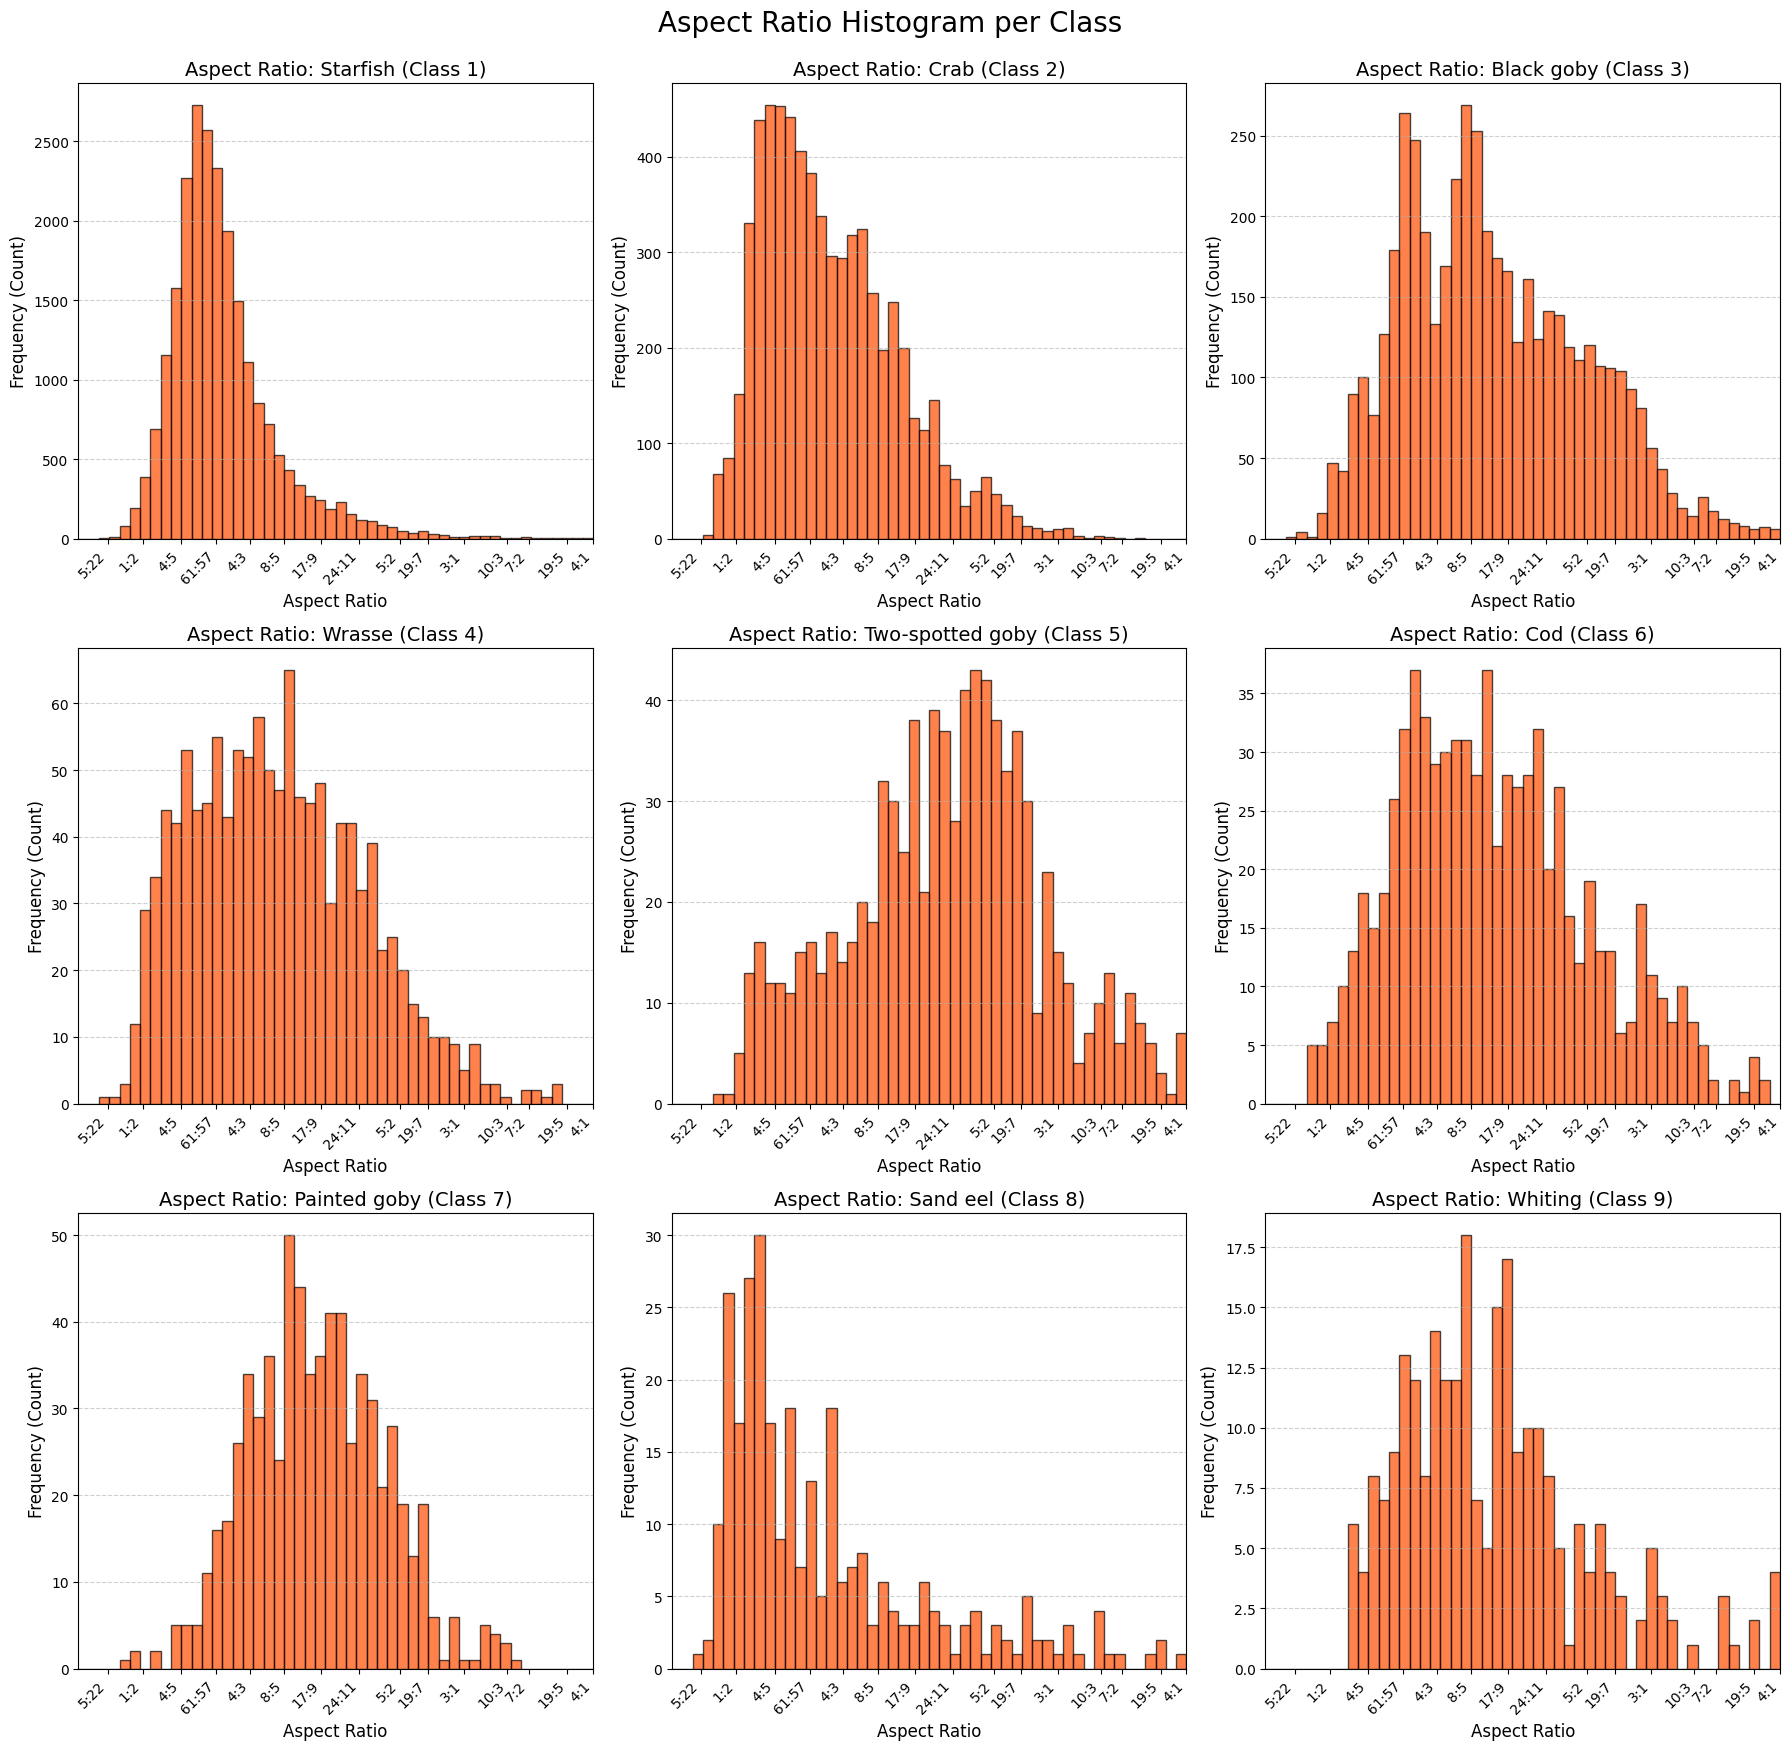

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
import os # Kept for completeness, though not strictly needed for this function alone

# --- Configuration (Keeping the same for context) ---
LABEL_MAP = {
    1: "Starfish", 2: "Crab", 3: "Black goby", 4: "Wrasse", 
    5: "Two-spotted goby", 6: "Cod", 7: "Painted goby", 8: "Sand eel", 
    9: "Whiting"
}

# --- Conversion Helper Function ---

def convert_ratios_to_float_list(ratio_counts_per_class):
    """
    Converts the dictionary of {'W:H': count} back into a dictionary of 
    {class_id: [float_ratio, float_ratio, ...]} suitable for np.histogram.
    """
    float_ratios_per_class = defaultdict(list)
    
    # The input structure is defaultdict(<function ...>, {class_id: defaultdict(int, {'ratio': count, ...})})
    for class_id, ratio_counts in ratio_counts_per_class.items():
        if isinstance(ratio_counts, dict): # Ensure it's the inner dictionary
            for ratio_str, count in ratio_counts.items():
                try:
                    # Parse the W:H string into integers
                    w_str, h_str = ratio_str.split(':')
                    width = int(w_str)
                    height = int(h_str)
                    
                    if height == 0:
                        print(f"Warning: Ratio {ratio_str} for Class {class_id} has a height of zero. Skipping.")
                        continue
                        
                    float_ratio = width / height
                    
                    # Duplicate the float ratio by the count
                    float_ratios_per_class[class_id].extend([float_ratio] * count)
                    
                except ValueError as e:
                    print(f"Error parsing ratio string '{ratio_str}' for Class {class_id}: {e}")
                except Exception as e:
                    print(f"An unexpected error occurred for ratio '{ratio_str}': {e}")
                    
    return float_ratios_per_class

# --- Plotting Logic (The core function for the histogram) ---

def plot_aspect_ratio_histograms_2(float_ratio_data, label_map):
    """
    Plots a true histogram of float ratios, with custom n:m labels on the x-axis.
    
    float_ratio_data: dictionary mapping class_id -> [list of float aspect ratios]
    """
    
    # Define common aspect ratio points for custom x-axis ticks
    CUSTOM_TICKS = [
    ('5:22', 0.227),
    ('1:2', 0.500),
    ('4:5', 0.800),
    ('61:57', 1.070),
    ('4:3', 1.333),
    ('8:5', 1.600),
    ('17:9', 1.889),
    ('24:11', 2.182),
    ('5:2', 2.500),
    ('19:7', 2.714),
    ('3:1', 3.000),
    ('10:3', 3.333),
    ('7:2', 3.500),
    ('19:5', 3.800),
    ('4:1', 4.000)
]
    tick_labels = [label for label, value in CUSTOM_TICKS]
    tick_positions = [value for label, value in CUSTOM_TICKS]

    # Dynamically determine the max ratio for the x-axis limit
    all_ratios = [ratio for ratios in float_ratio_data.values() for ratio in ratios]
    max_ratio = max(all_ratios) if all_ratios else 2.5
    
    # Set a sensible upper limit for the plot, rounding up to the nearest 0.5 or max 4.0
    plot_max_x = min(4.0, np.ceil(max_ratio * 2) / 2) 
    
    # Create the plot grid (assuming max of 9 classes)
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()
    
    for i in range(1, 10):
        ax = axes[i-1]
        class_name = label_map.get(i, f"Class {i} (Unknown)")
        ratios = float_ratio_data.get(i, [])
        
        ax.set_title(f'Aspect Ratio: {class_name} (Class {i})', fontsize=14)

        if not ratios:
            ax.text(0.5, 0.5, 'No Data', 
                    horizontalalignment='center', verticalalignment='center', 
                    transform=ax.transAxes, fontsize=16, color='gray')
            ax.set_xlabel('Aspect Ratio (W:H)', fontsize=12)
            ax.set_ylabel('Frequency (Count)', fontsize=12)
            ax.set_xlim(0.0, plot_max_x)
            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=10)
            ax.set_facecolor('#f0f0f0')
            continue

        # Plot the TRUE histogram using the float ratios
        # Bins: Using 50 bins from 0.0 up to the determined max X
        ax.hist(ratios, bins=50, range=(0.0, plot_max_x), color='#FF4D00', edgecolor='black', alpha=0.7)
        
        # --- Custom X-axis Labeling ---
        # 1. Filter ticks to only show within the actual plot range (0.0 to plot_max_x)
        visible_positions = [pos for pos in tick_positions if pos <= plot_max_x]
        visible_labels = [label for label, pos in zip(tick_labels, tick_positions) if pos <= plot_max_x]
        
        # 2. Set the positions and the ratio string labels
        ax.set_xticks(visible_positions)
        ax.set_xticklabels(visible_labels, rotation=45, ha='right', fontsize=10)
        
        ax.set_xlabel('Aspect Ratio', fontsize=12)
        ax.set_ylabel('Frequency (Count)', fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.set_ylim(bottom=0)
        ax.set_xlim(0.0, plot_max_x)


    # Adjust layout and save the figure
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.suptitle('Aspect Ratio Histogram per Class ', fontsize=20, y=1.00)
    
    # You would typically call plt.show() here or save the figure.
    output_filename = 'aspect_ratio_histograms_from_counts.png'
    plt.savefig(output_filename)
    print(f"\nPlot saved to {output_filename}")
    

# --- Example Execution (Using your provided data snippet for Class 1) ---



# 1. Convert the ratio-count format to the flat float list format
float_ratio_data_for_plot = convert_ratios_to_float_list(ratio_results)

# 2. Plot the results
if any(float_ratio_data_for_plot.values()):
    plot_aspect_ratio_histograms_2(float_ratio_data_for_plot, LABEL_MAP)
else:
    print("\nNo aspect ratio data to plot after conversion.")

In [14]:
ratio_results[1].keys()

dict_keys(['26:69', '63:58', '41:38', '27:31', '1:1', '13:17', '61:77', '74:61', '33:35', '57:65', '58:43', '3:2', '13:12', '31:48', '21:19', '84:71', '18:19', '8:5', '16:11', '83:104', '22:15', '52:57', '47:40', '43:49', '9:10', '44:49', '68:33', '98:59', '33:50', '9:14', '31:25', '43:47', '43:40', '29:17', '39:46', '27:23', '23:16', '31:20', '31:35', '21:22', '49:47', '15:13', '67:55', '52:51', '105:34', '16:15', '44:69', '17:26', '53:48', '87:71', '36:25', '63:67', '26:23', '26:47', '15:7', '13:15', '67:38', '55:52', '68:37', '4:11', '51:59', '59:60', '8:7', '44:29', '37:15', '19:50', '65:34', '85:36', '7:6', '51:79', '44:43', '12:11', '89:40', '59:39', '39:38', '63:52', '103:125', '46:27', '52:87', '31:45', '33:46', '29:23', '32:21', '4:5', '59:49', '24:23', '12:7', '75:44', '21:32', '41:43', '34:29', '62:57', '46:87', '27:26', '63:31', '34:37', '59:67', '100:29', '42:53', '55:49', '61:62', '19:35', '91:41', '7:15', '59:24', '65:79', '61:63', '19:16', '40:39', '23:17', '95:63', '34

In [11]:
import os
import re
from PIL import Image
from collections import defaultdict
import numpy as np # Added for potential future use (e.g., calculations on ratios)

# --- CONSTANTS & HELPER FUNCTIONS ---
LABEL_MAP = {
    1: "Starfish", 2: "Crab", 3: "Black goby", 4: "Wrasse", 
    5: "Two-spotted goby", 6: "Cod", 7: "Painted goby", 8: "Sand eel", 
    9: "Whiting"
}


BRIGHT_COLORS_K_F = [
    '#FF6600',  # Orange (KEPT)
    '#3366FF',  # Bright Blue (DELETED)
]

def extract_class_from_path(path):
    """
    Extract the single digit class ID (1-9) immediately preceded by an underscore 
    and followed by the file extension.
    """
    filename = os.path.basename(path)
    match = re.search(r"\_(\d)(?=\.[^\.]*$)", filename, flags=re.IGNORECASE)
    
    if not match:
        return -1 
    return int(match.group(1))

def extract_filtered_aspect_ratios_with_counts(kept_paths_file, deleted_paths_file):
    """
    Reads image paths, calculates the aspect ratio (width:height), and stores 
    the counts of each unique ratio string for 'kept' and 'deleted' status per class.
    
    Returns:
        dict: {
            class_id (int): {
                'kept': {'ratio_string': count, ...}, 
                'deleted': {'ratio_string': count, ...}
            }
        }
    """
    print("1. Extracting aspect ratio data and counts from filtered image path files...")
    
    # Initialize the nested dictionary structure:
    # {class_id: {status: {ratio_string: count}}}
    ratio_count_data = defaultdict(lambda: {
        'kept': defaultdict(int), 
        'deleted': defaultdict(int)
    })

    def process_file_list(file_path, status):
        """Helper function to read paths, calculate aspect ratio string, and count."""
        count = 0
        try:
            with open(file_path, 'r') as f:
                image_paths = [line.strip() for line in f if line.strip()]
        except FileNotFoundError:
            print(f"   Warning: File not found at {file_path}. Skipping {status} data.")
            return

        for path in image_paths:
            if not os.path.exists(path):
                continue

            class_id = extract_class_from_path(path)
            if class_id not in LABEL_MAP:
                continue

            try:
                img = Image.open(path)
                width, height = img.size
                
                # --- MODIFICATION: Store as "n:m" string ---
                # You specifically requested the string format, so we use the raw dimensions.
                ratio_string = f"{width}:{height}"
                
                ratio_count_data[class_id][status][ratio_string] += 1
                count += 1
            except Exception as e:
                print(f"   Skipping image {os.path.basename(path)} due to error: {e}")
        
        print(f"   Processed {count} {status} images.")

    process_file_list(kept_paths_file, 'kept')
    process_file_list(deleted_paths_file, 'deleted')
    
    # Convert inner defaultdicts to regular dicts for a cleaner final output, if desired
    final_data = {}
    for class_id, status_data in ratio_count_data.items():
        final_data[class_id] = {
            'kept': dict(status_data['kept']),
            'deleted': dict(status_data['deleted'])
        }
    
    return final_data

# Example of how to use the new function (assuming you have the files/paths):
# kept_data_ratios = extract_filtered_aspect_ratios('kept_paths.txt', 'deleted_paths.txt')
# print("\nExample output structure (first class):")
# for class_id, data in kept_data_ratios.items():
#     print(f"Class {class_id}: Kept Ratios ({len(data['kept'])}): {data['kept'][:5]}...")
#     print(f"Class {class_id}: Deleted Ratios ({len(data['deleted'])}): {data['deleted'][:5]}...")
#     break

In [12]:
KEPT_PATHS_FILE_MAHALA = "../mahala_median/kept_image_paths.txt"
DELETED_PATHS_FILE_MAHALA = "../mahala_median/filtered_out_image_paths.txt"
# -------------------------------------------

# 1. Extract and process the area data
aspect_ratio_data_by_status_mahala = extract_filtered_aspect_ratios_with_counts(KEPT_PATHS_FILE_MAHALA, DELETED_PATHS_FILE_MAHALA)

1. Extracting aspect ratio data and counts from filtered image path files...
   Processed 29047 kept images.
   Processed 9525 deleted images.


In [13]:

KEPT_PATHS_FILE_EU = "../euclidean_median/kept_image_paths.txt"
DELETED_PATHS_FILE_EU = "../euclidean_median/filtered_out_image_paths.txt"
    # -------------------------------------------
aspect_ratio_data_by_status_eu = extract_filtered_aspect_ratios_with_counts(KEPT_PATHS_FILE_EU, DELETED_PATHS_FILE_EU)

1. Extracting aspect ratio data and counts from filtered image path files...
   Processed 20110 kept images.
   Processed 10767 deleted images.


In [15]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from typing import Dict, List, Tuple, Any

# --- Configuration ---
LABEL_MAP: Dict[int, str] = {
    1: "Starfish", 2: "Crab", 3: "Black goby", 4: "Wrasse", 
    5: "Two-spotted goby", 6: "Cod", 7: "Painted goby", 8: "Sand eel", 
    9: "Whiting"
}

# --- Custom Ticks (As requested) ---
CUSTOM_TICKS: List[Tuple[str, float]] = [
    ('5:22', 0.227),
    ('1:2', 0.500),
    ('4:5', 0.800),
    ('61:57', 1.070),
    ('4:3', 1.333),
    ('8:5', 1.600),
    ('17:9', 1.889),
    ('24:11', 2.182),
    ('5:2', 2.500),
    ('19:7', 2.714),
    ('3:1', 3.000),
    ('10:3', 3.333),
    ('7:2', 3.500),
    ('19:5', 3.800),
    ('4:1', 4.000)
]
TICK_LABELS = [label for label, value in CUSTOM_TICKS]
TICK_POSITIONS = [value for label, value in CUSTOM_TICKS]

# Define colors for the overlaid histograms
COLORS = {
    'kept': '#FF6600',    # Bright orange
    'deleted': '#3366FF' # Bright blue
}

# --- Plotting Logic (MODIFIED CORE FUNCTION) ---

def plot_aspect_ratio_histograms_overlaid(ratio_count_data: Dict[int, Dict[str, Dict[str, int]]], label_map: Dict[int, str], filter_type):
    """
    Plots overlaid histograms of aspect ratios for 'kept' and 'deleted' images per class.
    
    ratio_count_data: dictionary mapping class_id -> 
                      {'kept': {'W:H': count, ...}, 'deleted': {'W:H': count, ...}}
    """
    
    # --- Internal Data Conversion (Replacing the standalone function) ---
    all_ratios = []
    
    # 1. Convert ratio counts to flat float lists and find max ratio
    float_ratio_data: Dict[int, Dict[str, List[float]]] = defaultdict(lambda: {'kept': [], 'deleted': []})
    
    for class_id, status_data in ratio_count_data.items():
        for status in ['kept', 'deleted']:
            ratio_counts = status_data.get(status, {})
            
            for ratio_str, count in ratio_counts.items():
                try:
                    w_str, h_str = ratio_str.split(':')
                    width = int(w_str)
                    height = int(h_str)
                    
                    if height == 0:
                        continue
                        
                    float_ratio = width / height
                    
                    # Store for plotting
                    ratios_list = [float_ratio] * count
                    float_ratio_data[class_id][status].extend(ratios_list)
                    
                    # Track for max X determination
                    all_ratios.extend(ratios_list)
                    
                except Exception:
                    # Skip any malformed ratio strings
                    pass

    # 2. Determine the maximum ratio for consistent x-axis range
    max_ratio = max(all_ratios) if all_ratios else 2.5
    
    # Set a sensible upper limit for the plot, using the next custom tick or max 4.0
    plot_max_x = min(4.0, max([pos for pos in TICK_POSITIONS if pos >= max_ratio], default=max_ratio))
    
    # 3. Create the plot grid
    fig, axes = plt.subplots(3, 3, figsize=(18, 18))
    axes = axes.flatten()
    
    # 4. Iterate through classes and plot
    for i in range(1, 10):
        ax = axes[i-1]
        class_name = label_map.get(i, f"Class {i} (Unknown)")
        
        kept_ratios = float_ratio_data.get(i, {}).get('kept', [])
        deleted_ratios = float_ratio_data.get(i, {}).get('deleted', [])
        
        ax.set_title(f'Aspect Ratio Distribution: {class_name} (Class {i})', fontsize=14)

        if not kept_ratios and not deleted_ratios:
            ax.text(0.5, 0.5, 'No Data', 
                    horizontalalignment='center', verticalalignment='center', 
                    transform=ax.transAxes, fontsize=16, color='gray')
            # Fall through to apply axis settings below
        else:
            # Plot the overlaid histograms
            bins = np.linspace(0.0, plot_max_x, 50) # Use 50 bins
            
            # Plot Deleted (first)
            ax.hist(deleted_ratios, bins=bins, color=COLORS['deleted'], 
                    alpha=0.6, label=f'Deleted ({len(deleted_ratios)})', 
                    edgecolor='black', linewidth=0.5)
            
            # Plot Kept (second)
            ax.hist(kept_ratios, bins=bins, color=COLORS['kept'], 
                    alpha=0.7, label=f'Kept ({len(kept_ratios)})', 
                    edgecolor='black', linewidth=0.5)

            ax.legend(loc='upper right', fontsize=10)
        
        # --- Custom X-axis Labeling ---
        visible_positions = [pos for pos in TICK_POSITIONS if pos <= plot_max_x]
        visible_labels = [label for label, pos in zip(TICK_LABELS, TICK_POSITIONS) if pos <= plot_max_x]
        
        ax.set_xticks(visible_positions)
        ax.set_xticklabels(visible_labels, rotation=45, ha='right', fontsize=10)
        
        ax.set_xlabel('Aspect Ratio', fontsize=8)
        ax.set_ylabel('Frequency (Count)', fontsize=12)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        ax.set_ylim(bottom=0)
        ax.set_xlim(0.0, plot_max_x)
        ax.set_facecolor('#f7f7f7')


    # 5. Adjust layout and save the figure
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.suptitle(f'Aspect Ratio Distribution Comparison (Kept vs. Deleted) - {filter_type}', fontsize=20, y=0.98)
    
    output_filename = f'aspect_ratio_comparison_histograms_{filter_type}.png'
    plt.savefig(output_filename)
    print(f"\nPlot saved to {output_filename}")







Plot saved to aspect_ratio_comparison_histograms_Mahalanobis.png


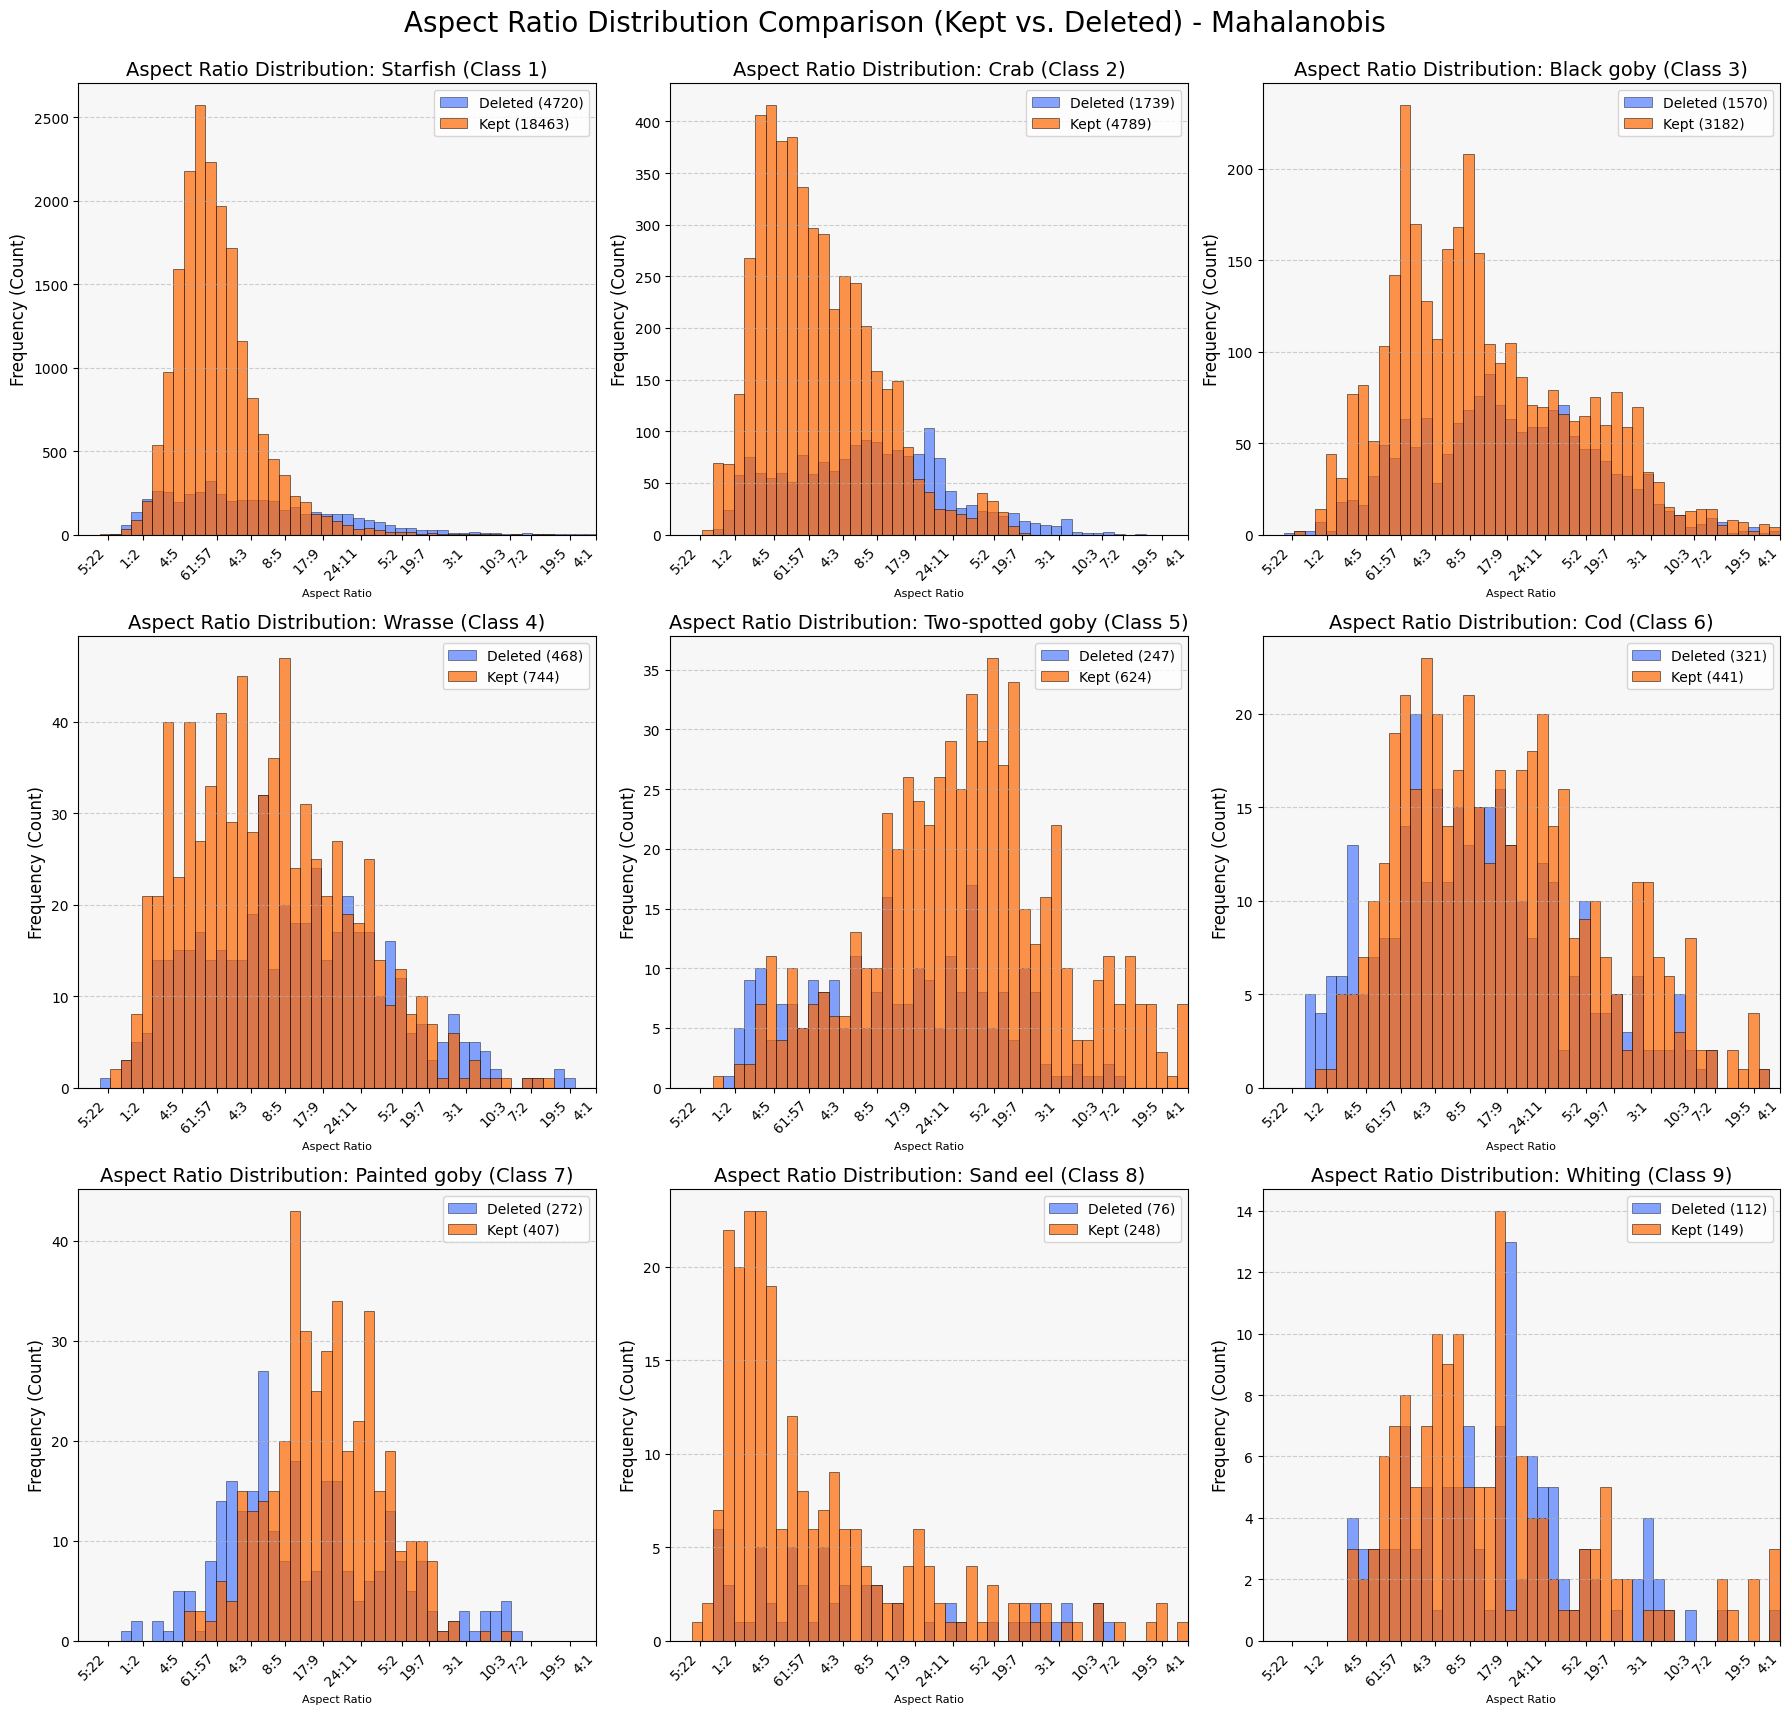

In [16]:
# Call the modified plotting function directly with the count dictionary
plot_aspect_ratio_histograms_overlaid(aspect_ratio_data_by_status_mahala, LABEL_MAP, filter_type="Mahalanobis")


Plot saved to aspect_ratio_comparison_histograms_Euclidean.png


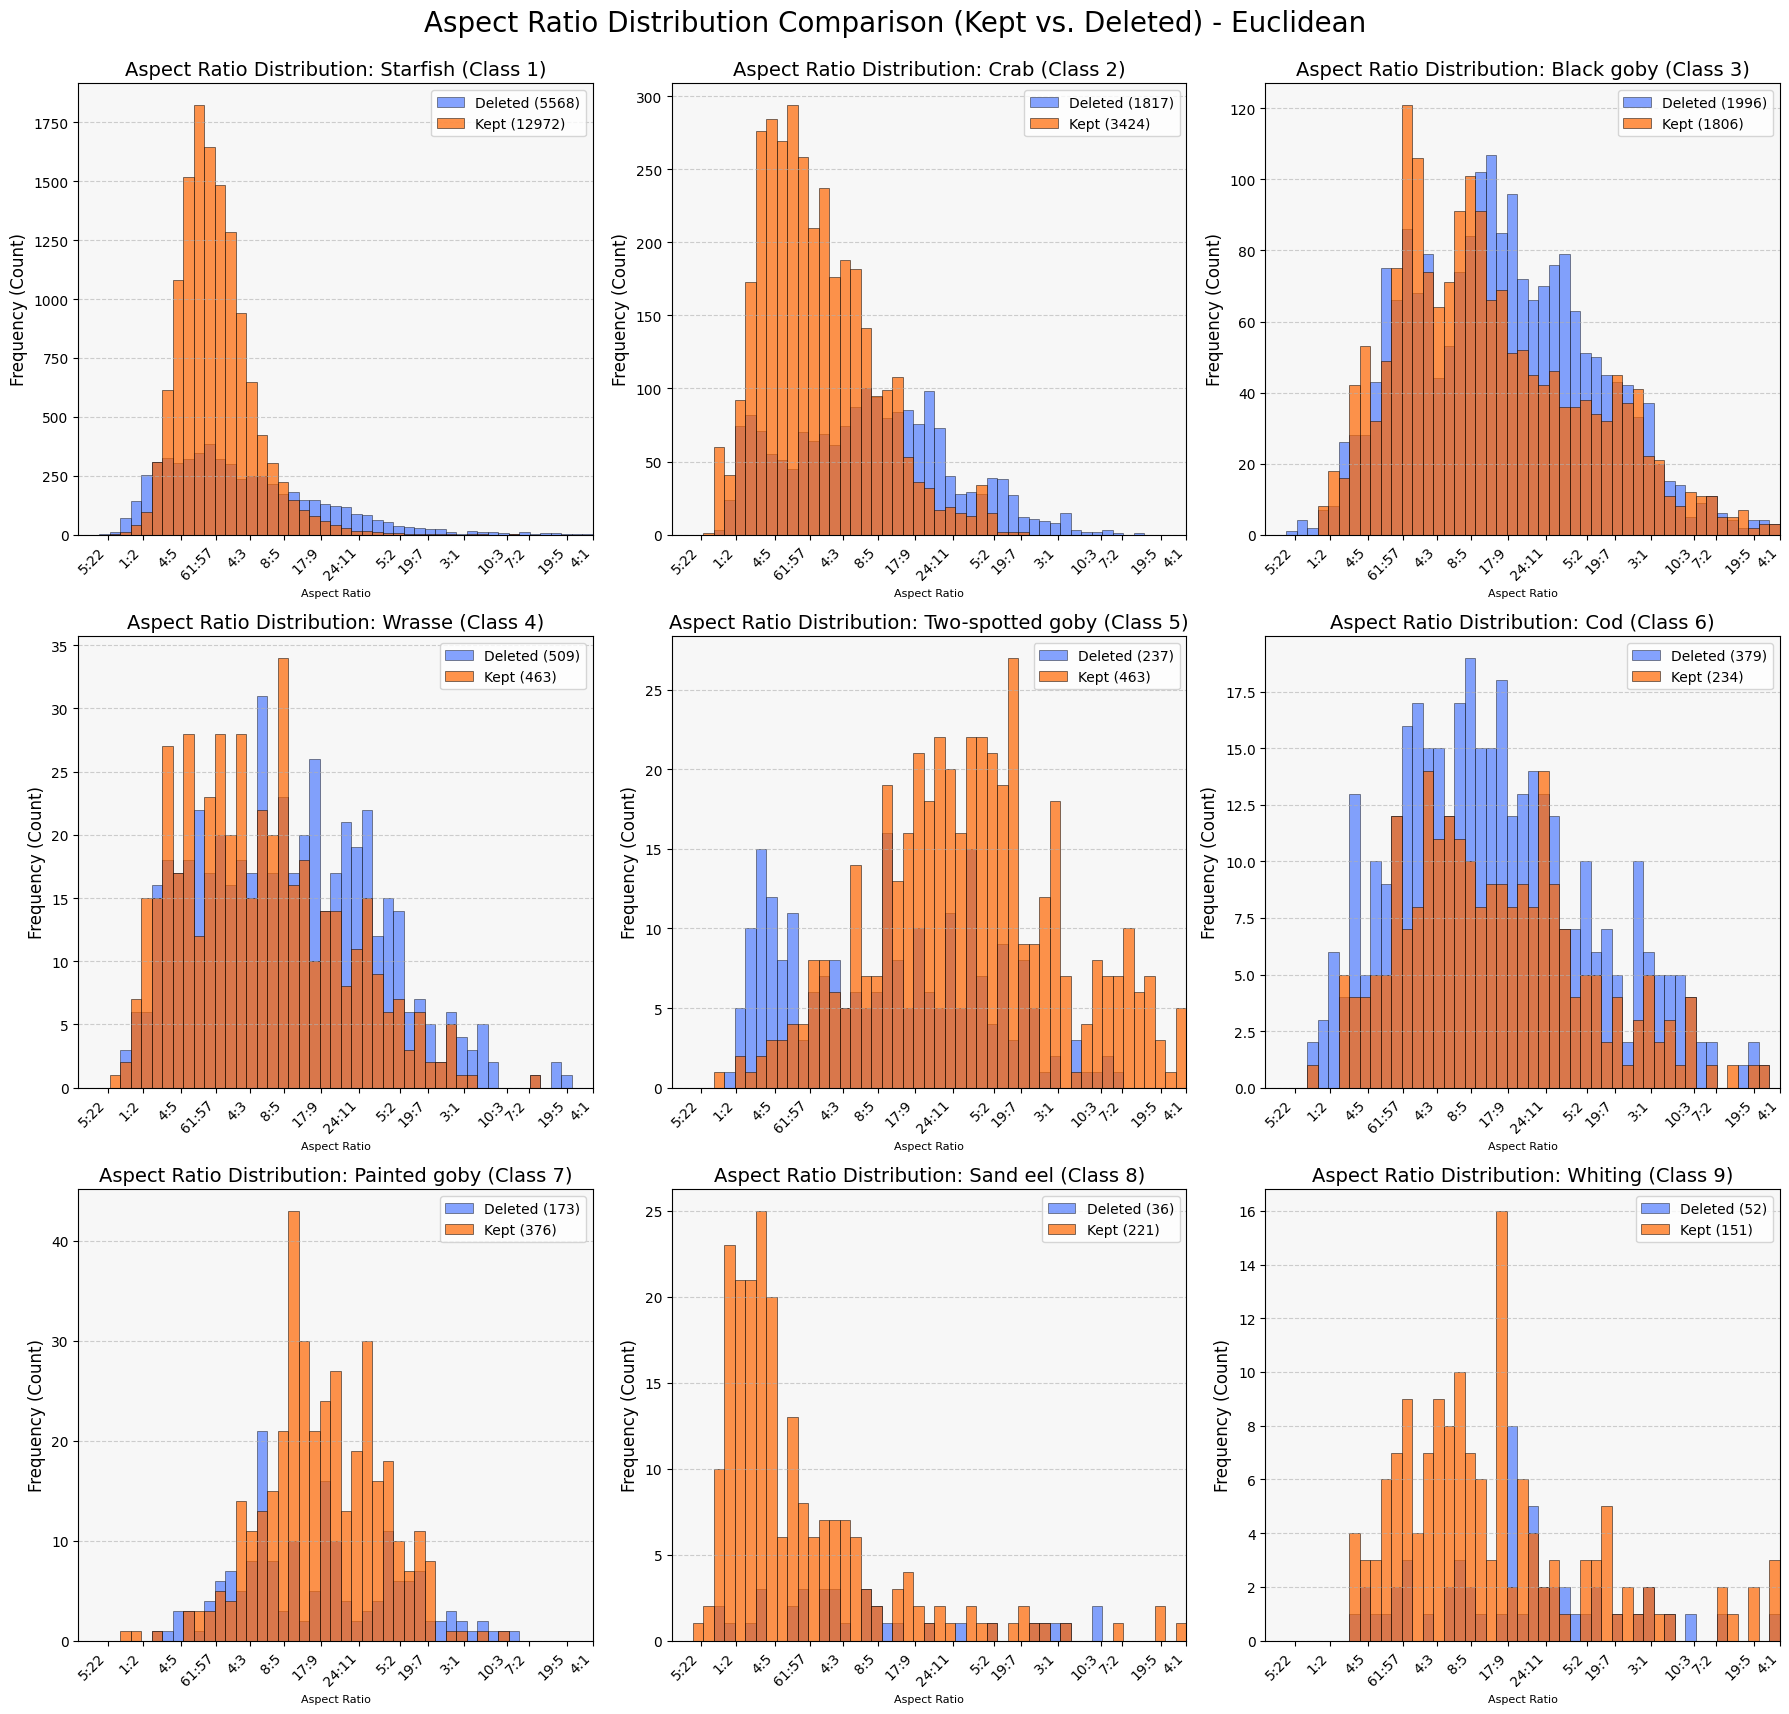

In [17]:
plot_aspect_ratio_histograms_overlaid(aspect_ratio_data_by_status_eu, LABEL_MAP, filter_type="Euclidean")